# 02 — Modelagem supervisionada

Constrói a pipeline completa de Machine Learning exigida pelo enunciado:
imputação, transformação de variáveis numéricas e categóricas, tratamento de
data leakage, pré-processamento acoplado ao modelo, treinamento, otimização,
validação e interpretabilidade.

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # torna o pacote `src` importável
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

In [2]:
from src.config import CORTE_ALFABETIZACAO, CV_FOLDS, RANDOM_STATE, TEST_SIZE
from src.data.build_abt import carregar_abt, validar_ausencia_de_vazamento
from src.preprocessing.features import ALVO_PRINCIPAL, CATEGORICAS, FEATURES, NUMERICAS

abt = carregar_abt()
print(f"{abt.shape[0]} municípios | {len(NUMERICAS)} numéricas | {len(CATEGORICAS)} categóricas")
validar_ausencia_de_vazamento(FEATURES, abt)

5396 municípios | 16 numéricas | 4 categóricas


{'preditores_avaliados': 20,
 'colunas_proibidas_encontradas': 0,
 'maior_correlacao_com_alvo': 0.651,
 'variavel_mais_correlacionada': 'media_portugues_2023'}

## 1. Separação treino/teste — a primeira defesa contra vazamento

A divisão acontece **antes** de qualquer estatística ser calculada. Nenhuma
média de imputação, nenhum desvio de padronização e nenhuma categoria de
encoding pode ver o conjunto de teste, ou as métricas ficariam otimistas.

A estratificação preserva a proporção de municípios alfabetizados nas duas
partes.

In [3]:
from src.modeling.train import separar_dados

X_tr, X_te, y_tr, y_te, taxa_tr, taxa_te = separar_dados(abt)

pd.DataFrame({
    "conjunto": ["treino", "teste"],
    "municipios": [len(X_tr), len(X_te)],
    "perc_alfabetizados": [round(y_tr.mean(), 4), round(y_te.mean(), 4)],
})

,conjunto,municipios,perc_alfabetizados
0,treino,4316,0.5695
1,teste,1080,0.5694


## 2. Pré-processamento integrado ao modelo

O `ColumnTransformer` é a **primeira etapa do Pipeline**, não um passo separado.
Duas consequências práticas:

- na validação cruzada, o imputador e o scaler são reajustados dentro de cada
  fold, sobre o fold de treino apenas;
- o artefato salvo em disco recebe dados crus e devolve predição — não existe
  preparação manual que possa divergir entre o notebook e a produção.

**Numéricas**: imputação pela mediana (robusta às caudas longas de população,
área e PIB) com indicador de ausência, seguida de padronização.
**Categóricas**: imputação pela moda e one-hot com `handle_unknown="ignore"`,
para que uma UF não vista no treino não quebre o modelo.

In [4]:
from src.preprocessing.pipeline import construir_preprocessador, montar_pipeline

preprocessador = construir_preprocessador()
preprocessador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per tr

In [5]:
# Quantas colunas o pré-processamento gera a partir das originais.
preprocessador.fit(X_tr)
nomes = list(preprocessador.get_feature_names_out())
print(f"{len(FEATURES)} colunas originais -> {len(nomes)} colunas transformadas")
print("Exemplos de colunas criadas:", [n for n in nomes if "missingindicator" in n.lower()][:4])
print("Exemplos de one-hot:", [n for n in nomes if n.startswith("sigla_uf")][:6])

20 colunas originais -> 64 colunas transformadas
Exemplos de colunas criadas: ['missingindicator_participacao_2023', 'missingindicator_taxa_estadual_2023', 'missingindicator_dif_municipal_estadual_2023', 'missingindicator_dif_municipal_privada_2023']
Exemplos de one-hot: ['sigla_uf_AL', 'sigla_uf_AM', 'sigla_uf_AP', 'sigla_uf_BA', 'sigla_uf_CE', 'sigla_uf_ES']


## 3. Comparação dos algoritmos por validação cruzada

Cinco candidatos, do mais simples ao mais flexível. A régua é a Regressão
Logística: se um modelo complexo não a supera com folga, o ganho não compensa a
perda de interpretabilidade.

A tabela reporta o ROC AUC de validação **e** o de treino. A diferença entre os
dois é a leitura direta de overfitting.

In [6]:
from src.modeling.train import comparar_modelos

ranking = comparar_modelos(X_tr, y_tr)
ranking

,modelo,roc_auc_val,roc_auc_desvio,roc_auc_treino,overfitting,f1_val,pr_auc_val,acuracia_val,tempo_fit_s
0,Random Forest,0.9032,0.0115,0.9760,0.0728,0.8447,0.9210,0.8190,14.49
1,Extra Trees,0.9030,0.0112,0.9503,0.0472,0.8443,0.9211,0.8197,9.64
2,Gradient Boosting,0.9012,0.0113,0.9680,0.0668,0.8359,0.9205,0.8093,2.61
3,Regressao Logistica,0.9008,0.0139,0.9067,0.0060,0.8462,0.9152,0.8228,0.70
4,Arvore de Decisao,0.8798,0.0110,0.9078,0.0280,0.8345,0.8837,0.8054,0.43


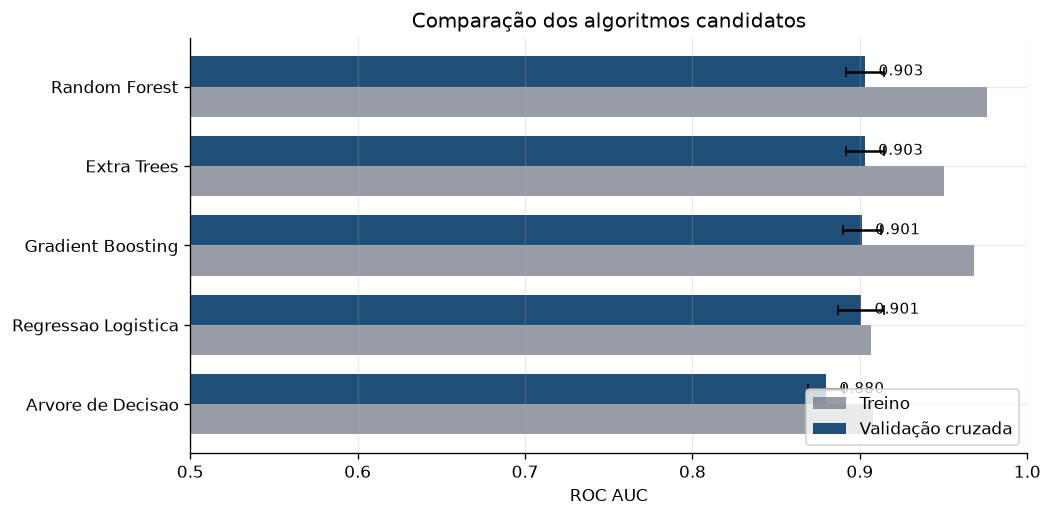

In [7]:
from IPython.display import Image, display
from src.visualization import plots

display(Image(filename=str(plots.comparacao_modelos(ranking))))

### A escolha do modelo — regra do erro-padrão

Os quatro primeiros modelos ficam separados por **milésimos** de ROC AUC, enquanto
o desvio entre os folds é da ordem de 0,011. A diferença está dentro do ruído:
escolher o primeiro da lista seria escolher acaso.

Aplicamos então a *one standard error rule*: entre todos os modelos a menos de um
desvio-padrão do melhor, fica o que **menos decorou o treino**. Os ensembles
chegam a 0,97 de AUC no treino contra 0,90 na validação — decoraram. A Regressão
Logística tem praticamente o mesmo desempenho de validação com uma diferença de
0,006 entre treino e validação.

Em política pública essa escolha vale duas vezes: o modelo mais simples generaliza
melhor fora da amostra e é defensável diante de um gestor que precisa entender por
que sua cidade entrou na lista de prioridades.

In [8]:
from src.modeling.train import escolher_modelo

nome_escolhido, justificativa = escolher_modelo(ranking)
print(justificativa)

Random Forest teve o maior ROC AUC (0.9032), mas Regressao Logistica ficou dentro de um desvio-padrão (0.9008) com overfitting de 0.0060 contra 0.0728. Pela regra do erro-padrão, vence o modelo mais simples e mais estável.


## 4. Otimização de hiperparâmetros

`RandomizedSearchCV` em vez de `GridSearchCV`: a grade completa passaria de mil
combinações, e a busca aleatória cobre o espaço com uma fração do custo chegando
a resultados equivalentes. A métrica otimizada é o ROC AUC, por ser independente
do limiar de decisão — o limiar é escolhido depois, por critério de política
pública.

In [9]:
from src.modeling.train import otimizar

busca = otimizar(nome_escolhido, X_tr, y_tr, n_iter=20)
print("Melhor ROC AUC (validação cruzada):", round(busca.best_score_, 4))
print("Parâmetros:", busca.best_params_)

(pd.DataFrame(busca.cv_results_)
   .sort_values("rank_test_score")
   .loc[:, ["params", "mean_train_score", "mean_test_score", "std_test_score"]]
   .head(8))

Melhor ROC AUC (validação cruzada): 0.9018
Parâmetros: {'modelo__penalty': 'l2', 'modelo__class_weight': 'balanced', 'modelo__C': 5}


,params,mean_train_score,mean_test_score,std_test_score
9,"{'modelo__penalty': 'l2', 'modelo__class_weigh...",0.907976,0.901786,0.013625
8,"{'modelo__penalty': 'l2', 'modelo__class_weigh...",0.907884,0.901736,0.013642
10,"{'modelo__penalty': 'l2', 'modelo__class_weigh...",0.908016,0.901689,0.013423
11,"{'modelo__penalty': 'l2', 'modelo__class_weigh...",0.908090,0.901658,0.013493
7,"{'modelo__penalty': 'l2', 'modelo__class_weigh...",0.906843,0.900963,0.013948
6,"{'modelo__penalty': 'l2', 'modelo__class_weigh...",0.906713,0.900758,0.013942
5,"{'modelo__penalty': 'l2', 'modelo__class_weigh...",0.905812,0.900092,0.014068
4,"{'modelo__penalty': 'l2', 'modelo__class_weigh...",0.905633,0.899927,0.013952


## 5. Calibração das probabilidades

Um classificador pode acertar o *ranking* e ainda assim errar a *probabilidade*.
Para ranquear municípios por risco, o ranking bastaria; para dizer "este
município tem 30% de chance de alcançar o patamar", a probabilidade precisa
corresponder à frequência real.

A calibração isotônica é ajustada com validação cruzada **interna ao treino** —
o conjunto de teste continua intocado.

In [10]:
from sklearn.calibration import CalibratedClassifierCV

calibrado = CalibratedClassifierCV(busca.best_estimator_, method="isotonic", cv=5)
calibrado.fit(X_tr, y_tr)

prob_bruta = busca.best_estimator_.predict_proba(X_te)[:, 1]
prob_calibrada = calibrado.predict_proba(X_te)[:, 1]
print("pronto")

pronto


In [11]:
from src.evaluation.metrics import calibracao, painel_de_metricas

comparacao = pd.DataFrame([
    {"versao": "sem calibração", **painel_de_metricas(y_te, prob_bruta)},
    {"versao": "calibrada", **painel_de_metricas(y_te, prob_calibrada)},
])
comparacao[["versao", "roc_auc", "pr_auc", "brier", "acuracia", "f1", "recall_risco"]]

,versao,roc_auc,pr_auc,brier,acuracia,f1,recall_risco
0,sem calibração,0.9029,0.9260,0.1256,0.8231,0.8412,0.8237
1,calibrada,0.9024,0.9246,0.1246,0.8213,0.8422,0.8000


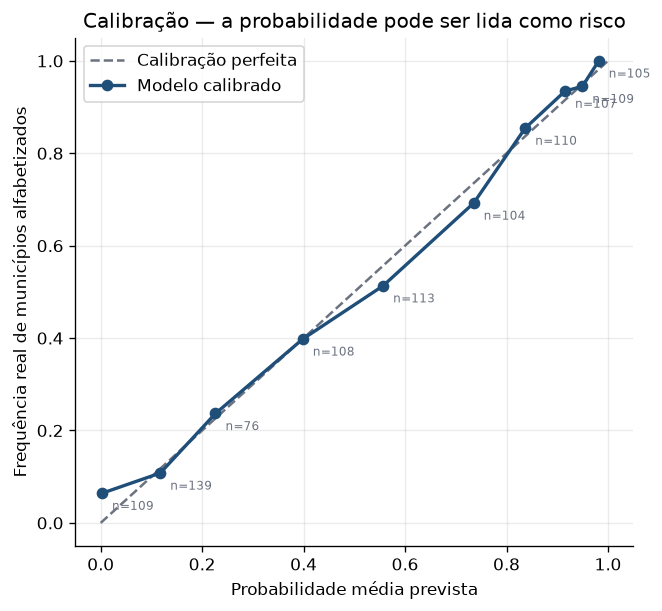

,faixa,n,prob_media_prevista,frequencia_real,erro_absoluto
0,"(-0.001, 0.0166]",109,0.0026,0.0642,0.0616
1,"(0.0166, 0.159]",139,0.1174,0.1079,0.0095
2,"(0.159, 0.295]",76,0.2263,0.2368,0.0106
3,"(0.295, 0.453]",108,0.3985,0.3981,0.0003
4,"(0.453, 0.671]",113,0.5568,0.5133,0.0435
5,"(0.671, 0.791]",104,0.7353,0.6923,0.0430
6,"(0.791, 0.869]",110,0.8369,0.8545,0.0176
7,"(0.869, 0.937]",107,0.9154,0.9346,0.0192
8,"(0.937, 0.959]",109,0.9495,0.9450,0.0045
9,"(0.959, 1.0]",105,0.9818,1.0000,0.0182


In [12]:
tabela_calibracao = calibracao(y_te, prob_calibrada)
display(Image(filename=str(plots.curva_de_calibracao(tabela_calibracao))))
tabela_calibracao

Os pontos caem praticamente sobre a diagonal: entre os municípios a que o modelo
atribui 40% de chance, cerca de 40% de fato alcançam o patamar. É essa
propriedade que sustenta a leitura no aluno.

## 6. A ponte entre o município e o aluno

Se a probabilidade prevista acompanha a taxa real de alfabetização do município,
ela pode ser lida como estimativa da proporção de alunos alfabetizados — que é a
pergunta do enunciado.

In [13]:
from src.evaluation.metrics import comparar_com_taxa_real

ponte = comparar_com_taxa_real(prob_calibrada, taxa_te, CORTE_ALFABETIZACAO)
print(ponte)

fig, eixo = plt.subplots(figsize=(6.5, 5))
eixo.scatter(prob_calibrada, taxa_te, s=8, alpha=0.3, color="#1f4e79")
eixo.axhline(CORTE_ALFABETIZACAO, linestyle="--", color="#c62828",
             label=f"Corte do alvo ({CORTE_ALFABETIZACAO:.0f}%)")
eixo.set_xlabel("Probabilidade prevista de o município alcançar o patamar")
eixo.set_ylabel("Taxa real de alfabetização em 2024 (%)")
eixo.set_title(f"Probabilidade prevista x taxa observada (r = {ponte['correlacao_pearson']:.2f})")
eixo.legend(); eixo.grid(alpha=0.25)
plt.show()

{'correlacao_pearson': 0.7663, 'correlacao_spearman': 0.7824, 'corte_usado': 60.0}


## 7. Avaliação no conjunto de teste

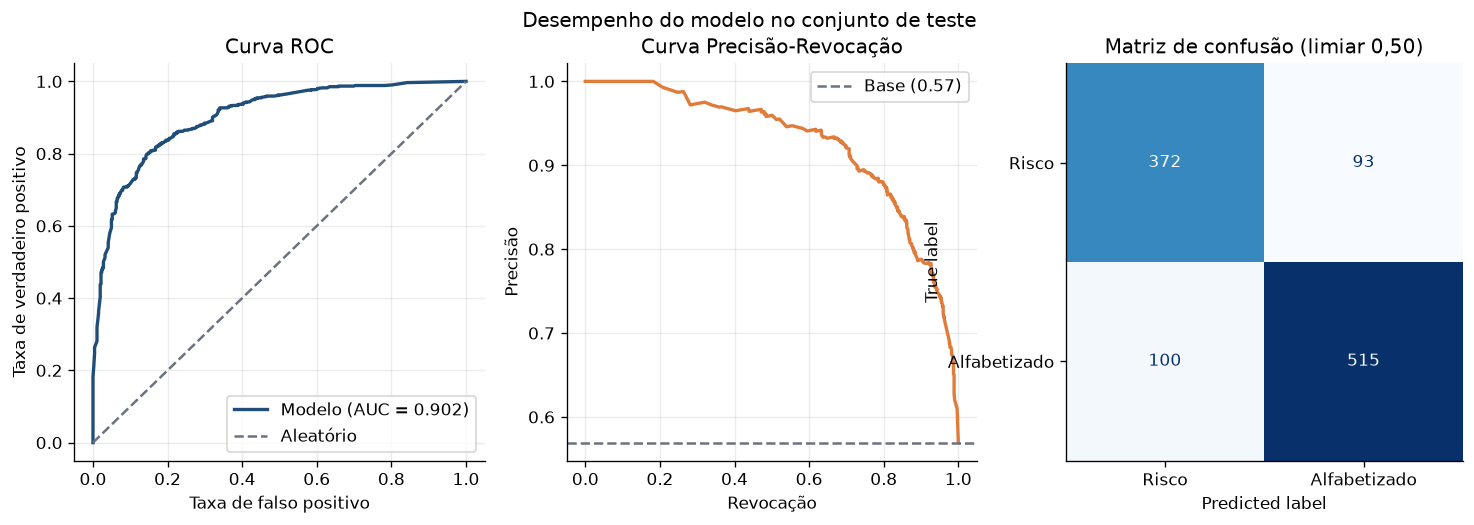

{'limiar': 0.5,
 'acuracia': 0.8213,
 'precisao': 0.847,
 'recall': 0.8374,
 'f1': 0.8422,
 'roc_auc': 0.9024,
 'pr_auc': 0.9246,
 'brier': 0.1246,
 'recall_risco': np.float64(0.8),
 'vp': 515,
 'vn': 372,
 'fp': 93,
 'fn': 100}

In [14]:
display(Image(filename=str(plots.curvas_de_desempenho(y_te, prob_calibrada))))
painel_de_metricas(y_te, prob_calibrada)

## 8. Escolha do limiar sob a ótica da política pública

O limiar de 0,50 é uma convenção matemática, não uma decisão de gestão. Os dois
erros possíveis custam coisas diferentes:

- classificar como "vai bem" um município que na verdade está em risco significa
  **deixar de mandar apoio a quem precisa** — criança que fica sem política;
- classificar como "em risco" um município que já ia bem significa **gastar apoio
  a mais** — desperdício orçamentário, recuperável.

Ponderamos o primeiro erro com peso 3 e o segundo com peso 1, e varremos os
limiares em busca do menor custo esperado.

Limiar de menor custo: 0.77


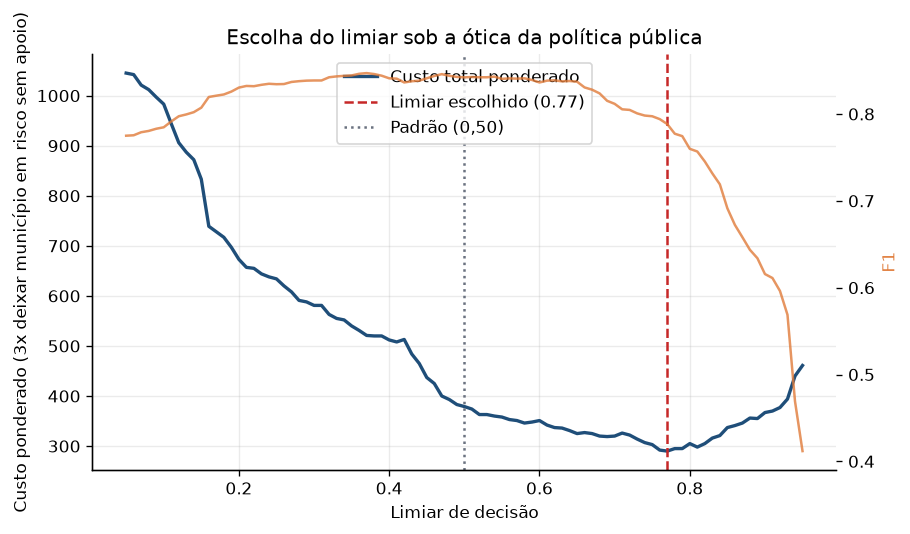

,limiar,f1,precisao,recall,risco_nao_detectado,apoio_desnecessario,custo_total
limiar escolhido,0.77,0.7884,0.9294,0.6846,32.0,194.0,290.0


In [15]:
from src.evaluation.metrics import limiar_otimo, otimizar_limiar

varredura = otimizar_limiar(y_te, prob_calibrada, custo_fn=3.0, custo_fp=1.0)
limiar = limiar_otimo(y_te, prob_calibrada)
print("Limiar de menor custo:", limiar)

display(Image(filename=str(plots.limiar_e_custo(varredura, limiar))))
varredura.loc[varredura["custo_total"].idxmin()].to_frame("limiar escolhido").T

In [16]:
pd.DataFrame([
    {"limiar": "0,50 (padrão)", **painel_de_metricas(y_te, prob_calibrada, 0.5)},
    {"limiar": f"{limiar} (custo de política)", **painel_de_metricas(y_te, prob_calibrada, limiar)},
])[["limiar", "acuracia", "precisao", "recall", "f1", "recall_risco", "fp", "fn"]]

,limiar,acuracia,precisao,recall,f1,recall_risco,fp,fn
0,0.50,0.8213,0.8470,0.8374,0.8422,0.8000,93,100
1,0.77,0.7907,0.9294,0.6846,0.7884,0.9312,32,194


O limiar mais alto troca precisão por cobertura: o modelo passa a exigir mais
evidência para dizer que um município está seguro, e com isso a detecção de
municípios em risco (`recall_risco`) sobe. É exatamente o comportamento que a
assimetria de custos pede.

## 9. Generalização — três testes

O primeiro é a curva de aprendizado (viés x variância). O segundo é a validação
geográfica, mais dura: treinar sem uma região inteira e testar nela.

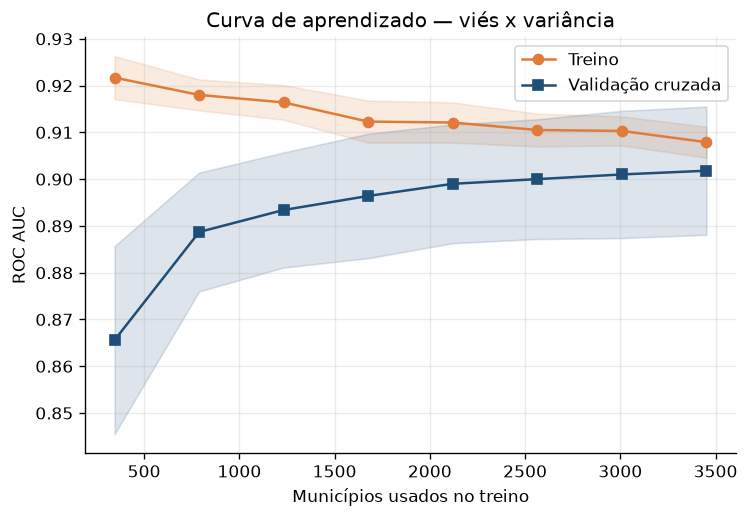

,n_treino,roc_auc_treino,roc_auc_treino_desvio,roc_auc_validacao,roc_auc_validacao_desvio
0,345,0.9217,0.0046,0.8656,0.0201
1,789,0.9180,0.0033,0.8887,0.0127
2,1232,0.9164,0.0037,0.8934,0.0123
3,1676,0.9123,0.0045,0.8964,0.0133
4,2120,0.9121,0.0043,0.8990,0.0127
5,2564,0.9105,0.0035,0.9000,0.0128
6,3008,0.9103,0.0031,0.9010,0.0136
7,3452,0.9079,0.0033,0.9018,0.0137


In [17]:
from src.modeling.train import curva_de_aprendizado

curva = curva_de_aprendizado(busca.best_estimator_, X_tr, y_tr)
display(Image(filename=str(plots.curva_de_aprendizado(curva))))
curva

In [18]:
from src.modeling.train import validacao_geografica

X_full = pd.concat([X_tr, X_te])
y_full = pd.concat([y_tr, y_te])
geo = validacao_geografica(busca.best_estimator_, X_full, y_full, X_full["regiao"])
geo

,regiao_de_teste,n_municipios,roc_auc,f1,acuracia
0,Nordeste,1779,0.7796,0.6000,0.7212
1,Norte,413,0.7704,0.5283,0.6973
2,Sudeste,1612,0.7383,0.7495,0.6700
3,Centro-Oeste,462,0.7023,0.7468,0.6537
4,Sul,1130,0.6625,0.7645,0.6805


**O resultado mais importante deste notebook.** O ROC AUC cai de 0,90 para a
faixa de 0,66–0,78 quando o modelo precisa opinar sobre uma região que nunca viu.

A explicação é direta: parte relevante do sinal está nas variáveis territoriais.
Ao remover a região inteira do treino, o one-hot de UF e região daquela região
fica todo em zero e o modelo perde essa informação — sobram apenas o histórico e
o contexto socioeconômico.

A consequência prática é honesta e precisa constar do relatório: **o modelo serve
para priorizar municípios dentro do Brasil de hoje, não para extrapolar a um
território de estrutura desconhecida.** Para uso federal, isso basta — todas as
regiões estão representadas na base.

## 10. Interpretabilidade — quais fatores mais impactam a alfabetização

Duas leituras complementares. A **importância por permutação** mede quanto o
desempenho cai ao embaralhar cada variável no conjunto de teste; é calculada
sobre as colunas originais e não sofre o viés da importância por impureza. Os
**valores SHAP** decompõem cada predição individual, com sinal.

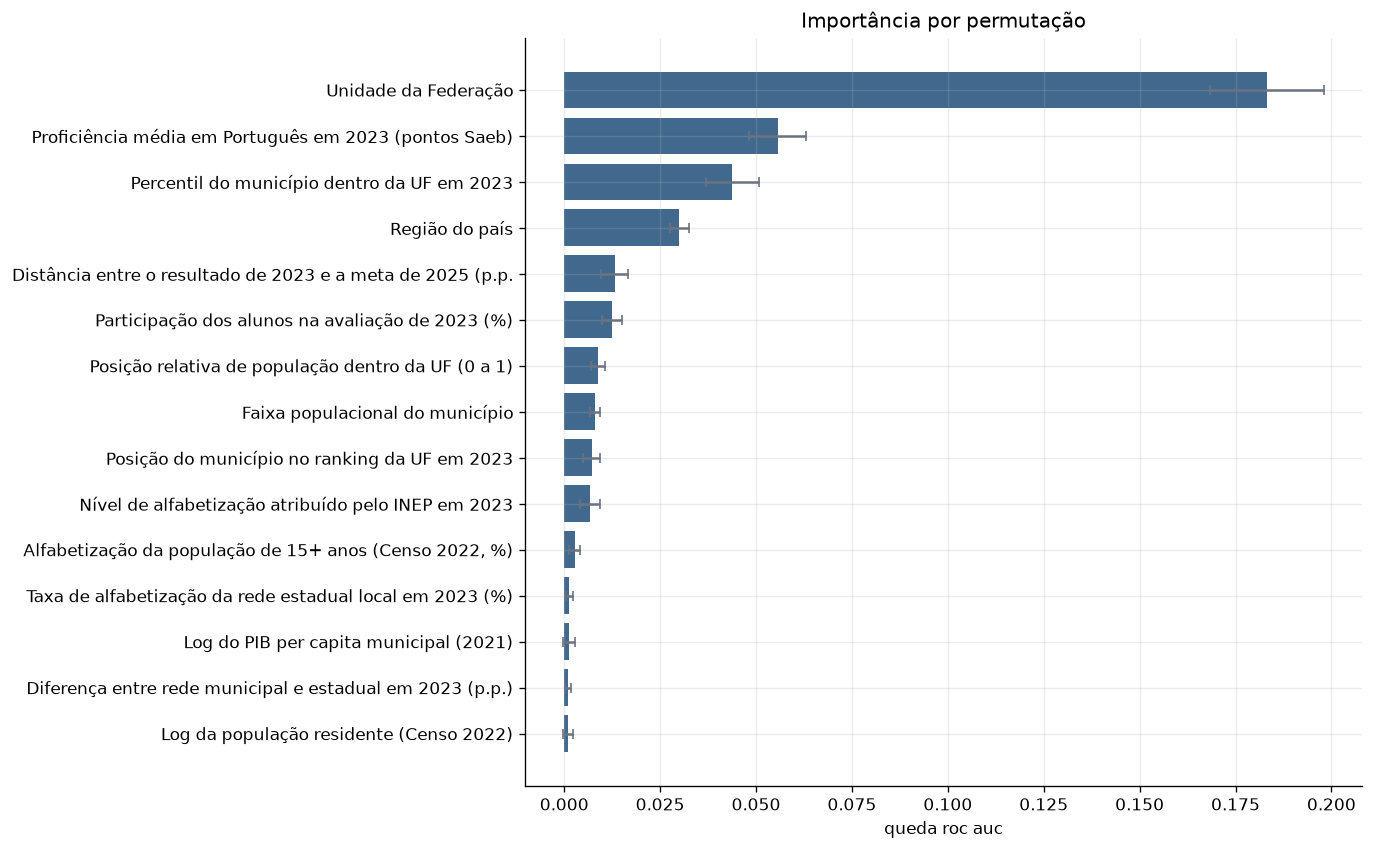

,descricao,queda_roc_auc,desvio
0,Unidade da Federação,0.18313,0.01491
1,Proficiência média em Português em 2023 (ponto...,0.05563,0.00744
2,Percentil do município dentro da UF em 2023,0.04385,0.00686
3,Região do país,0.03001,0.00247
4,Distância entre o resultado de 2023 e a meta d...,0.01315,0.00352
5,Participação dos alunos na avaliação de 2023 (%),0.01249,0.00263
6,Posição relativa de população dentro da UF (0 ...,0.00876,0.00183
7,Faixa populacional do município,0.00801,0.00124
8,Posição do município no ranking da UF em 2023,0.00714,0.00222
9,Nível de alfabetização atribuído pelo INEP em ...,0.00662,0.00258


In [19]:
from src.evaluation.interpretability import importancia_por_permutacao

importancia = importancia_por_permutacao(calibrado, X_te[FEATURES], y_te)
display(Image(filename=str(plots.importancia_variaveis(importancia))))
importancia.head(12)[["descricao", "queda_roc_auc", "desvio"]]

Background dataset has 400 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=400 when initializing the masker.


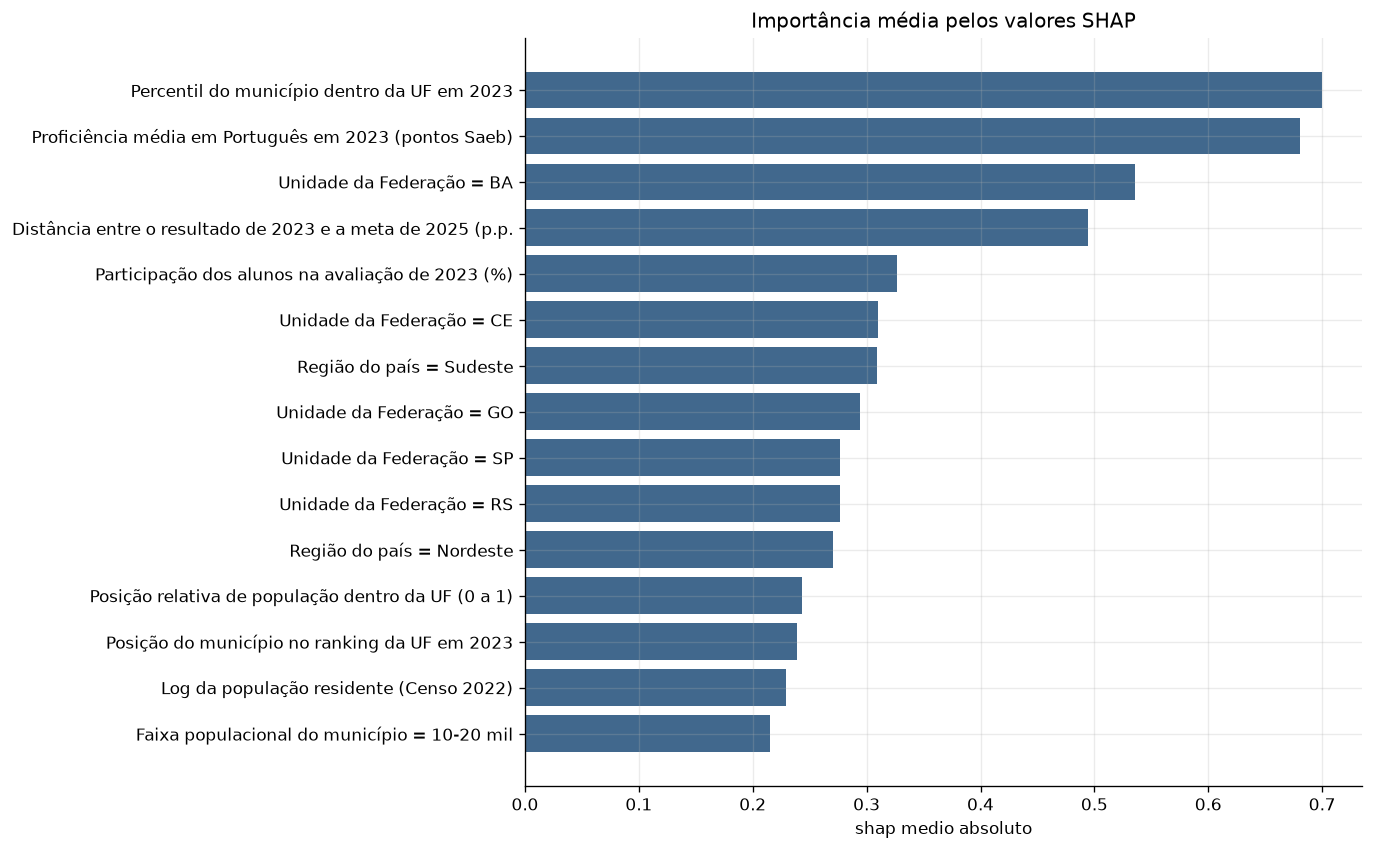

,descricao,shap_medio_absoluto,direcao
0,Percentil do município dentro da UF em 2023,0.69993,aumenta a chance
1,Proficiência média em Português em 2023 (ponto...,0.68011,aumenta a chance
2,Unidade da Federação = BA,0.53574,reduz a chance
3,Distância entre o resultado de 2023 e a meta d...,0.49405,reduz a chance
4,Participação dos alunos na avaliação de 2023 (%),0.32663,aumenta a chance
5,Unidade da Federação = CE,0.31024,reduz a chance
6,Região do país = Sudeste,0.30921,aumenta a chance
7,Unidade da Federação = GO,0.29446,reduz a chance
8,Unidade da Federação = SP,0.27671,reduz a chance
9,Unidade da Federação = RS,0.27646,reduz a chance


In [20]:
from src.evaluation.interpretability import valores_shap

shap_saida = valores_shap(busca.best_estimator_, X_te[FEATURES])
if shap_saida["disponivel"]:
    display(Image(filename=str(plots.importancia_variaveis(
        shap_saida["ranking"], coluna="shap_medio_absoluto",
        titulo="Importância média pelos valores SHAP",
        nome="10b_importancia_shap"))))
    display(shap_saida["ranking"].head(12)[["descricao", "shap_medio_absoluto", "direcao"]])
else:
    print(shap_saida["motivo"])

### Explicando um município específico

O que torna o modelo utilizável por um gestor não é o ranking global, é a
resposta para *a cidade dele*.

In [21]:
from src.evaluation.interpretability import explicar_municipio

if shap_saida["disponivel"]:
    indice = shap_saida["X_transformado"].index[0]
    municipio = abt.loc[indice]
    print(f"{municipio['nome_municipio']} ({municipio['sigla_uf']})")
    print(f"  taxa em 2023: {municipio['taxa_alf_2023']:.1f}%")
    print(f"  taxa em 2024: {municipio['taxa_alvo']:.1f}%  ->  alvo = {municipio['alfabetizado']}")
    print(f"  probabilidade prevista: {calibrado.predict_proba(abt.loc[[indice], FEATURES])[0, 1]:.3f}")
    display(explicar_municipio(busca.best_estimator_, X_te[FEATURES], indice, shap_saida))

Mortugaba (BA)
  taxa em 2023: 69.0%
  taxa em 2024: 60.0%  ->  alvo = 1
  probabilidade prevista: 0.129


,variavel,valor_padronizado,contribuicao_shap,descricao,efeito
0,sigla_uf_BA,1.000,-3.2110,Unidade da Federação = BA,puxa para nao alfabetizado
1,percentil_uf_2023,1.684,1.4133,Percentil do município dentro da UF em 2023,puxa para alfabetizado
2,regiao_Nordeste,1.000,-0.4181,Região do país = Nordeste,puxa para nao alfabetizado
3,porte_municipio_10-20 mil,1.000,0.3733,Faixa populacional do município = 10-20 mil,puxa para alfabetizado
4,ranking_uf_2023,-1.041,-0.3221,Posição do município no ranking da UF em 2023,puxa para nao alfabetizado
5,media_portugues_2023,0.235,0.3035,Proficiência média em Português em 2023 (ponto...,puxa para alfabetizado
6,participacao_2023,0.692,0.3001,Participação dos alunos na avaliação de 2023 (%),puxa para alfabetizado
7,log_pib_per_capita,-1.300,-0.2444,Log do PIB per capita municipal (2021),puxa para nao alfabetizado


## 11. Ranking de risco educacional

Aplicando o modelo a todos os municípios, sai o entregável direto para a gestão:
a lista de quem precisa de atenção, com a probabilidade calibrada e a distância
para a meta pactuada.

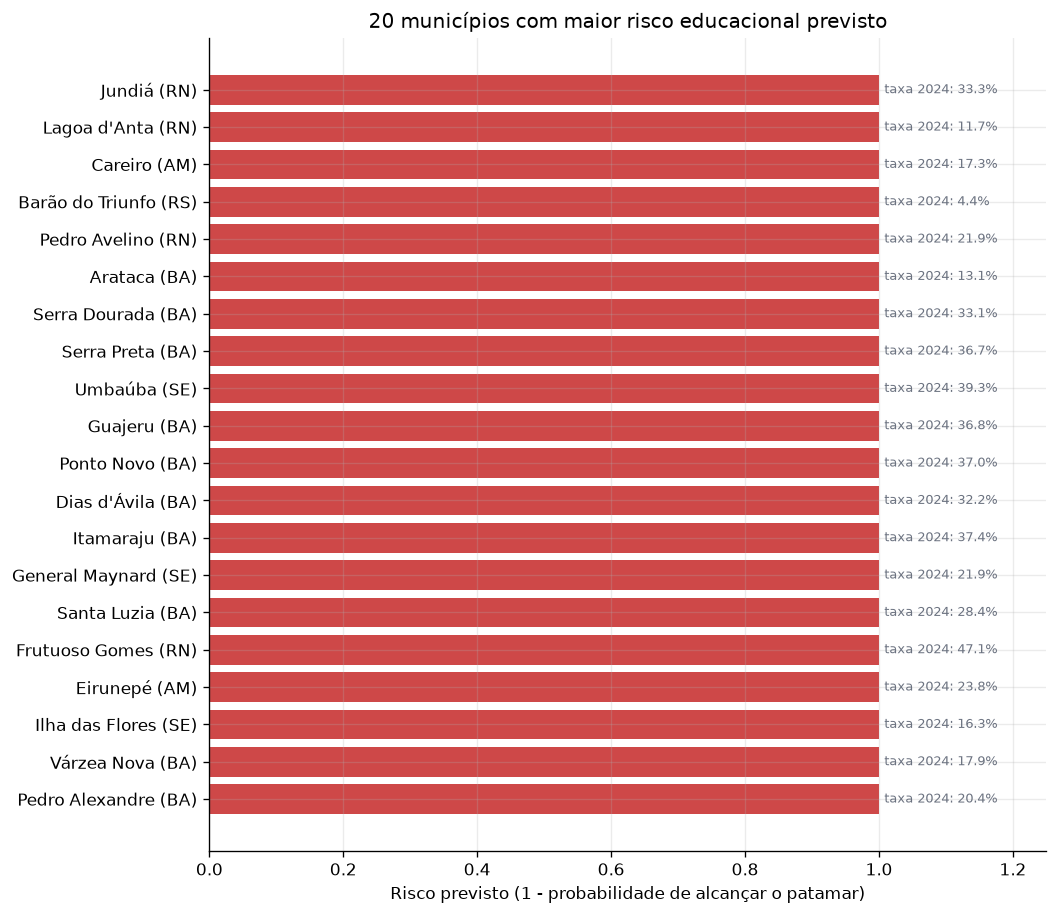

Distribuição por faixa de risco:


,municípios
faixa_de_risco,
Baixo,2373
Critico,1411
Alto,933
Moderado,679


,posicao,nome_municipio,sigla_uf,taxa_alvo,probabilidade_alfabetizar,faixa_de_risco
0,1,Jundiá,RN,33.33,0.0,Critico
1,2,Lagoa d'Anta,RN,11.65,0.0,Critico
2,3,Careiro,AM,17.29,0.0,Critico
3,4,Barão do Triunfo,RS,4.40,0.0,Critico
4,5,Pedro Avelino,RN,21.89,0.0,Critico
5,6,Arataca,BA,13.11,0.0,Critico
6,7,Serra Dourada,BA,33.09,0.0,Critico
7,8,Serra Preta,BA,36.67,0.0,Critico
8,9,Umbaúba,SE,39.34,0.0,Critico
9,10,Guajeru,BA,36.78,0.0,Critico


In [22]:
from src.evaluation.interpretability import ranking_de_risco

ranking_risco = ranking_de_risco(calibrado, abt, limiar)
display(Image(filename=str(plots.ranking_risco(ranking_risco))))

print("Distribuição por faixa de risco:")
display(ranking_risco["faixa_de_risco"].value_counts().to_frame("municípios"))
ranking_risco.head(15)[["posicao", "nome_municipio", "sigla_uf", "taxa_alvo",
                        "probabilidade_alfabetizar", "faixa_de_risco"]]

## 12. Síntese

| Etapa | Decisão | Resultado |
|---|---|---|
| Separação | Estratificada, 80/20, antes de qualquer ajuste | Sem vazamento treino→teste |
| Pré-processamento | Dentro do Pipeline, com indicador de ausência | Reajustado por fold |
| Escolha do modelo | Regra do erro-padrão | Regressão Logística, overfitting de 0,006 |
| Otimização | RandomizedSearchCV, ROC AUC | ~0,90 na validação cruzada |
| Calibração | Isotônica com CV interna | Brier melhora, probabilidade utilizável |
| Limiar | Custo assimétrico 3:1 | Mais cobertura dos municípios em risco |
| Generalização | Deixar uma região de fora | AUC cai a 0,66–0,78 — limitação declarada |
| Interpretação | Permutação + SHAP | Histórico, posição na UF e contexto adulto |

Próximo notebook: **03 — segmentação não supervisionada**.